In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Funciones

In [223]:
def compute_all_relative_regret(
    df: pd.DataFrame,
    df_random: pd.DataFrame,
    baseline_method: str = "Full-data",
    random_method: str = "random",
    metric_col: str = "test_balanced"
) -> pd.DataFrame:
    """
    Dado un df con columnas [method, model, IPC, <metric_col>], calcula
    el regret relativo para TODOS los métodos (incluido random), usando:
    
      AF = metric de baseline_method (Full-data), por model
      AR = metric de random_method, por (model, IPC)
      A  = metric de cada método, por (model, IPC)
    
    Retorna un df con columnas:
      [method, model, IPC, A, AR, AF, regret, (opcional) regret_clipped]
    """

    mean_metric_col = f'mean_{metric_col}'
    df_mean = (
        df.groupby(['method','model','IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
    )
    df_mean_random = (
        df_random.groupby(['method','model','IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
    )

    # 1) Extrae AF (una fila por model)
    df_AF = (
        df[df['method'] == baseline_method]
        .set_index('model')[metric_col]
        .rename('AF')
        .to_frame()
    )

    df_AR = (
        df_mean_random[
            (df_mean_random['method'] == random_method) &
            (df_mean_random['IPC'] == 10)
        ]
        .set_index('model')[mean_metric_col]
        .rename('AR')
        .to_frame()
    )

    # 3) Extrae A (todos los métodos salvo full-data) por model+IPC+method
    df_A = (
        df_mean[df_mean['method'] != baseline_method]
        .set_index(['method','model','IPC'])[mean_metric_col]
        .rename('A')
        .to_frame()
        .reset_index()
    )

    #display(df_AF)
    #display(df_AR)

    df_join_AF_AR = df_AF.join(df_AR, how='inner')
    df_join_AF_AR['AF_minus_AR'] = df_join_AF_AR['AF'] - df_join_AF_AR['AR']

    #display(df_join_AF_AR)

    # 5) Cálculo de regret
    def _compute(r):
        raw_compared = df_join_AF_AR.loc[r['model']]
        denom = raw_compared['AF_minus_AR']
        
        if denom == 0 or pd.isna(denom):
            return np.nan
        if denom < 0:
            print("Denominador menor que cero")
        return (raw_compared['AF'] - r['A']) / denom

    df_A['regret'] = df_A.apply(_compute, axis=1)

    return df_A

In [224]:
def plot_regret_grid(
    rr_original,
    rr_lat,
    rr_lat_ft,
    rr_random,
    models: list[str],
    methods: list[str],
    ipc_values: list[float],
    colors: dict[str,str] = None
):
    """
    Dibuja una grilla [n_modelos x n_métodos] de curvas de regret vs IPC.

    Parámetros
    ----------
    rr_original : DataFrame
        relative regret para cada (model, IPC, method) en espacio original.
    rr_lat : DataFrame
        idem, en espacio latente.
    rr_lat_ft : DataFrame
        idem, latente + fine-tuning.
    rr_random : DataFrame
        baseline random: debe contener columnas ['model','IPC','regret'].
    models : lista de modelos (strings coincidiendo con .model en los dfs).
    methods: lista de métodos de destilación (strings coincidiendo con .method).
    ipc_values: lista de valores de IPC a plotear (para ordenar el eje X).
    colors : dict opcional { método: color_hex } para cada método.
    """
    # Colores por método (fallback si no se pasa)
    default_colors = {
        'k-means':'#1f77b4', 
        'ag':'#d62728', 
        'gm':'#9467bd', 
        'kip':'#2ca02c'
    }
    colors = colors or default_colors

    n_models = len(models)
    n_methods = len(methods)
    fig, axes = plt.subplots(
        n_models, n_methods,
        #figsize=(n_methods*4, n_models*3),
        figsize=(12,8),
        sharex=True, sharey=True
    )
    if n_models==1: axes = axes[None, :]
    if n_methods==1: axes = axes[:, None]

    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i][j]
            c = colors.get(method, 'gray')
            # 1) Random baseline (negro, sólido)
            df_rnd = rr_random[
                (rr_original['model']==model)
            ]
            ax.plot(
                df_rnd['IPC'], df_rnd['regret'],
                '-', color='black', lw=1.5, label='RND'
            )
            # 2) Original-space
            df_o = rr_original[
                (rr_original['model']==model)&
                (rr_original['method']==method)
            ]
            ax.plot(
                df_o['IPC'], df_o['regret'],
                '-', color='blue', lw=1.5, label=f'{method} Orig.'
            )
            # 3) Latent-space
            df_l = rr_lat[
                (rr_lat['model']==model)&
                (rr_lat['method']==method)
            ]
            ax.plot(
                df_l['IPC'], df_l['regret'],
                '--', color='orange', lw=1.5, label=f'{method} Lat.'
            )
            # 4) Latent+FT
            df_f = rr_lat_ft[
                (rr_lat_ft['model']==model)&
                (rr_lat_ft['method']==method)
            ]
            ax.plot(
                df_f['IPC'], df_f['regret'],
                '-.', color='g', lw=1.5, label=f'{method} Lat FT'
            )

            ax.set_title(f"{model.upper()} - {method.upper()}")
            if i == n_models-1:
                ax.set_xlabel("Instances Per Class")
            if j == 0:
                ax.set_ylabel("Relative Regret")
            ax.set_xlim(min(ipc_values), max(ipc_values))
            ax.set_ylim(0,2)
            ax.grid(True, alpha=0.2)
            if i==0 and j==0:
                ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

# Analisis de shoppers

In [225]:
df_metrics_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal_A/metrics.csv')
df_metrics_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_A/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft_A/metrics.csv')

In [226]:
df_metrics_lat.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time'],
      dtype='object')

In [227]:
df_metrics_original[['model','test_balanced','test_roc_auc','IPC']][(df_metrics_original['IPC'].isin([90,np.nan])) & (df_metrics_original['model'] == 'xgb')]

,model,test_balanced,test_roc_auc,IPC
0,xgb,0.769,0.930,NaN
1205,xgb,0.835,0.900,90.0
1210,xgb,0.512,0.862,90.0
1215,xgb,0.825,0.897,90.0
1220,xgb,0.805,0.867,90.0
1225,xgb,0.769,0.807,90.0
1230,xgb,0.331,0.165,90.0
1235,xgb,0.831,0.893,90.0
1240,xgb,0.498,0.878,90.0
1245,xgb,0.718,0.882,90.0


Calculo de test roc auc

In [228]:
metric = 'test_roc_auc'
#metric = 'test_balanced'

df_random = df_metrics_original[df_metrics_original.method == 'random']

rr_original = compute_all_relative_regret(df_metrics_original, df_random, metric_col=metric)
rr_lat = compute_all_relative_regret(df_metrics_lat,df_random, metric_col=metric)
rr_lat_ft = compute_all_relative_regret(df_metrics_lat_ft,df_random, metric_col=metric)
rr_random = rr_original.loc[rr_original.method == 'random']

In [229]:
rr_random.shape, rr_original.shape

((65, 5), (390, 5))

In [230]:
rr_random.head()

,method,model,IPC,A,regret
325,random,logreg,10.0,0.8278,1.000000
326,random,logreg,20.0,0.8386,0.854447
327,random,logreg,30.0,0.8592,0.576819
328,random,logreg,40.0,0.8604,0.560647
329,random,logreg,50.0,0.8650,0.498652


In [231]:
rr_original.head()

,method,model,IPC,A,regret
0,ag,logreg,10.0,0.8610,0.552561
1,ag,logreg,20.0,0.7198,2.455526
2,ag,logreg,30.0,0.6796,2.997305
3,ag,logreg,40.0,0.6854,2.919137
4,ag,logreg,50.0,0.6866,2.902965


In [232]:
rr_original.method.unique()

array(['ag', 'craig', 'k-means', 'k_center', 'lc', 'random'], dtype=object)

/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rnd = rr_random[
/tmp/ipykernel_24849/1555086338.py:54: Us

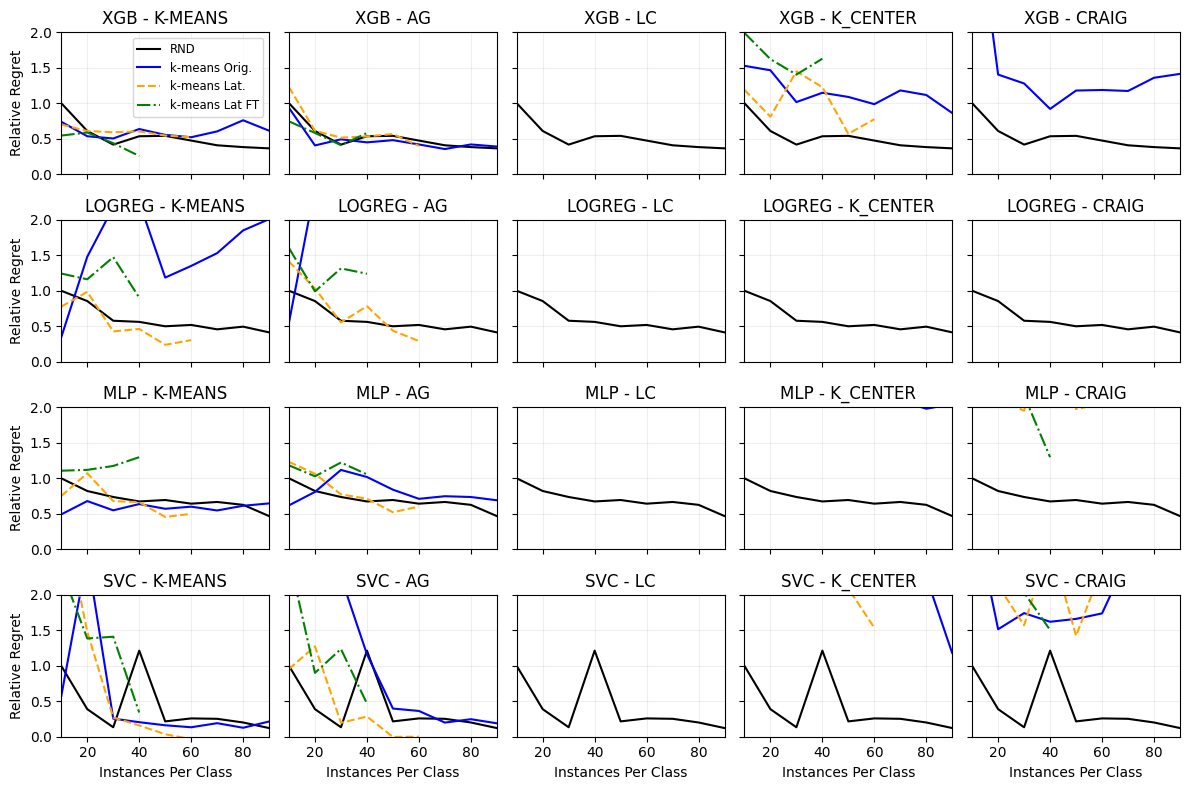

In [236]:
models = ['xgb','logreg','mlp','svc']
methods = ['k-means','ag','lc','k_center','craig']
ipc_values = sorted(rr_original['IPC'].unique())[:9]

plot_regret_grid(
    rr_original=rr_original,
    rr_lat=rr_lat,
    rr_lat_ft=rr_lat_ft,
    rr_random = rr_random,
    models=models,
    methods=methods,
    ipc_values=ipc_values
)

# Otras cosas

In [17]:
df_metrics_original[['model','method','IPC','seed','test_balanced']].head(5)

,model,method,IPC,seed,test_balanced
0,xgb,Full-data,NaN,NaN,0.769
1,rf,Full-data,NaN,NaN,0.854
2,svc,Full-data,NaN,NaN,0.771
3,logreg,Full-data,NaN,NaN,0.702
4,mlp,Full-data,NaN,NaN,0.783


In [10]:
df_metrics_lat.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.898,0.903,0.930,0.000017,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.853,0.787,0.877,0.866,0.010,0.007,0.005,0.006,...,0.882,0.872,0.921,0.000043,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.897,0.902,0.885,0.000259,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.757,0.778,0.889,0.893,0.006,0.007,0.004,0.004,...,0.881,0.884,0.911,0.000041,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_metrics_lat_ft.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.898,0.903,0.930,0.000013,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.850,0.786,0.876,0.865,0.009,0.008,0.005,0.007,...,0.878,0.867,0.921,0.000023,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.897,0.902,0.885,0.000258,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.767,0.787,0.893,0.897,0.010,0.009,0.004,0.004,...,0.893,0.896,0.924,0.000011,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_rr_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal_A/relative_regret.csv')
df_rr_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_A/relative_regret.csv')
df_rr_lat_tf = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft_A/relative_regret.csv')

In [6]:
df_rr_lat.head()

,method,ipc,model,regret_mean,regret_std
0,k-means,10,xgb,-0.277472,0.597593
1,k-means,10,rf,1.258424,0.445051
2,k-means,10,svc,3.467534,6.828530
3,k-means,10,logreg,0.099832,2.501407
4,k-means,10,mlp,0.093178,0.884185


In [ ]:
compute_relative_regret